# Time Series Analysis and Forecasting with ARIMA

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Visualize the data

In [22]:
df = pd.read_csv('Solar_data.csv')
df.head()

,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01T00:00:00Z,21665.0,1
1,2016-01-01T01:00:00Z,20260.0,0
2,2016-01-01T02:00:00Z,19056.0,0
3,2016-01-01T03:00:00Z,18407.0,0
4,2016-01-01T04:00:00Z,18425.0,0


In [23]:
# Convert utc_timestamp to datetime
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

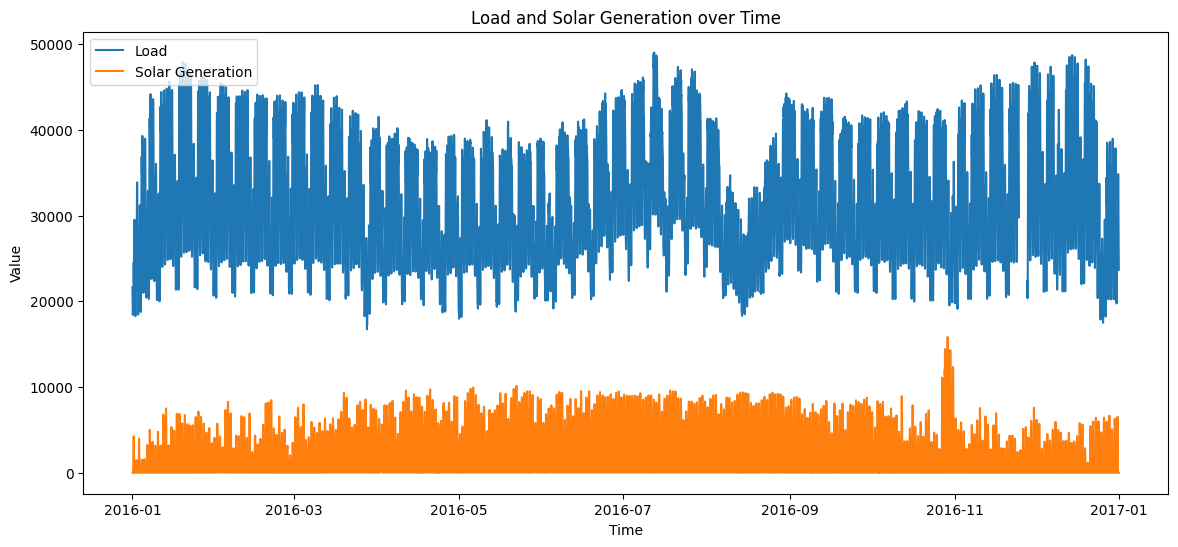

In [24]:
# Plot the data
plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'], df['IT_load_new'], label='Load')
plt.plot(df['utc_timestamp'], df['IT_solar_generation'], label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Load and Solar Generation over Time')
plt.show()

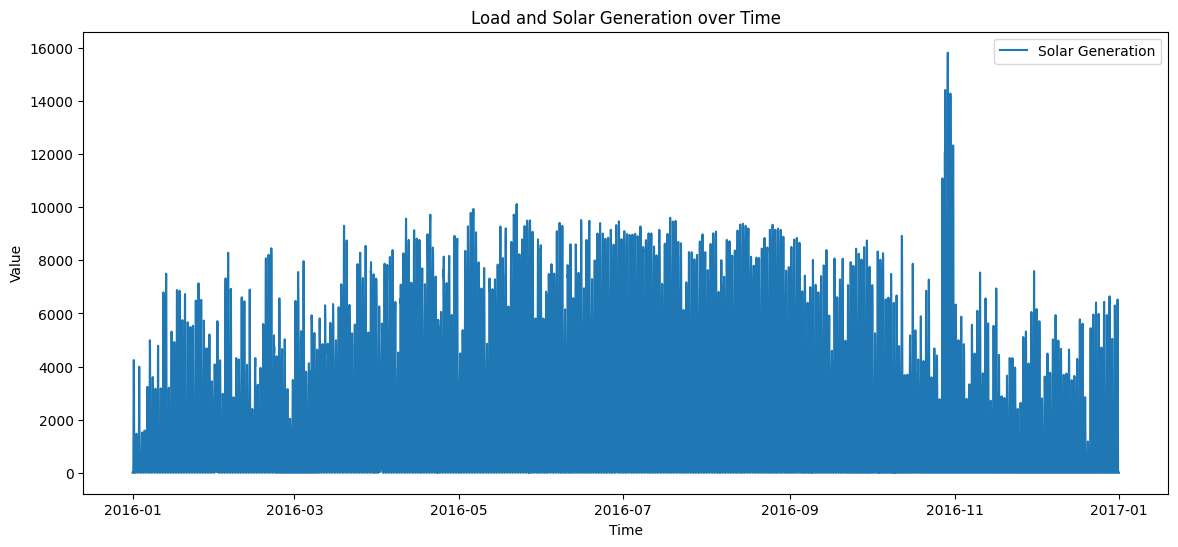

In [25]:
# Convert utc_timestamp to datetime
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Plot the data
plt.figure(figsize=(14,6))

#plt.plot(data['utc_timestamp'], data['IT_load_new'], label='Load')
plt.plot(df['utc_timestamp'], df['IT_solar_generation'], label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Load and Solar Generation over Time')
plt.show()

The 2016 plot reveals daily cyclical electricity loads alongside seasonal, day-night solar generation patterns. Before applying ARIMA forecasting, this data must be stationary, maintaining a constant mean and variance. To verify this, we perform an Augmented Dickey-Fuller test; a p-value under 0.05 rejects the null hypothesis, confirming the data's stationarity.

In [26]:
# Check for missing values
df.isnull().sum()

,0
utc_timestamp,0
IT_load_new,72
IT_solar_generation,0


In [27]:
# Fill missing values using forward fill
df['IT_load_new'] = df['IT_load_new'].ffill()

# Check for missing values again
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
utc_timestamp          0
IT_load_new            0
IT_solar_generation    0
dtype: int64


In [28]:
# Check for stationarity
from statsmodels.tsa.stattools import adfuller

# Function to perform Augmented Dickey-Fuller test
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

In [29]:
# Perform Augmented Dickey-Fuller test again
print("\nADF test for 'IT_load_new' after filling missing values:")
adf_test(df['IT_load_new'])

print("\nADF test for 'IT_solar_generation':")
adf_test(df['IT_solar_generation'])


ADF test for 'IT_load_new' after filling missing values:
Results of Dickey-Fuller Test:
Test Statistic                -1.197390e+01
p-value                        3.841445e-22
#Lags Used                     3.700000e+01
Number of Observations Used    8.746000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861871e+00
Critical Value (10%)          -2.566946e+00
dtype: float64

ADF test for 'IT_solar_generation':
Results of Dickey-Fuller Test:
Test Statistic                -5.741335e+00
p-value                        6.265438e-07
#Lags Used                     3.600000e+01
Number of Observations Used    8.747000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861870e+00
Critical Value (10%)          -2.566946e+00
dtype: float64


In [30]:
# Perform test for 'IT_load_new'
print("ADF test for 'IT_load_new':")
adf_test(df['IT_load_new'])

# Perform test for 'IT_solar_generation'
print("\nADF test for 'IT_solar_generation':")
adf_test(df['IT_solar_generation'])

ADF test for 'IT_load_new':
Results of Dickey-Fuller Test:
Test Statistic                -1.197390e+01
p-value                        3.841445e-22
#Lags Used                     3.700000e+01
Number of Observations Used    8.746000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861871e+00
Critical Value (10%)          -2.566946e+00
dtype: float64

ADF test for 'IT_solar_generation':
Results of Dickey-Fuller Test:
Test Statistic                -5.741335e+00
p-value                        6.265438e-07
#Lags Used                     3.600000e+01
Number of Observations Used    8.747000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861870e+00
Critical Value (10%)          -2.566946e+00
dtype: float64


ADF tests confirm both 'IT_load_new' and 'IT_solar_generation' are stationary, allowing us to build ARIMA forecasting models. ARIMA relies on parameters p (autoregressive lags), d (differencing), and q (moving average). Because our series are already stationary, d=0. Next, we will analyze ACF and PACF plots to determine optimal p and q.

## Build ARIMA model for 'IT_load_new'

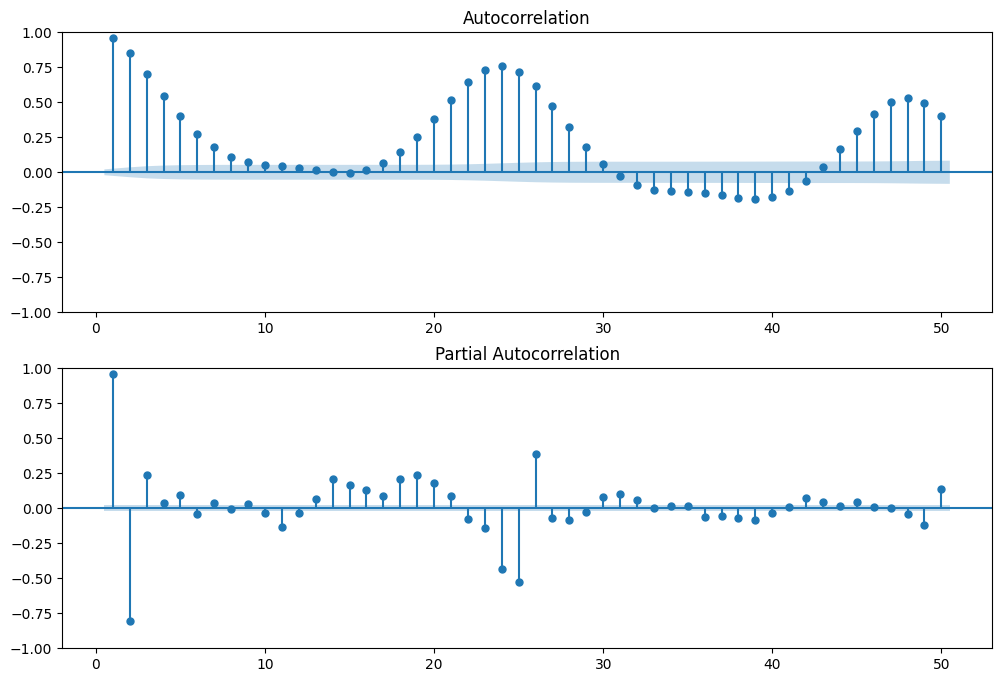

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
plot_acf(df['IT_load_new'], lags=50, zero=False, ax=ax1)
plot_pacf(df['IT_load_new'], lags=50, zero=False, ax=ax2)
plt.show()

Based on the gradual ACF decrease and sharp PACF drop after lag 2, we set ARIMA parameters p=2, q=2. We'll fit 'IT_load_new' using an 80/20 train-test split to evaluate performance.

In [32]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split the data into training and test sets
train_size = int(len(df['IT_load_new']) * 0.8)
train, test = df['IT_load_new'][:train_size], df['IT_load_new'][train_size:]

# Fit the ARIMA model
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

# Make predictions on the test set
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, predictions))
rmse

7714.95213482925

In [33]:
# Fit the ARIMA model
model2 = ARIMA(train, order=(2,1,2))
model_fit2 = model2.fit()

# Make predictions on the test set
predictions2 = model_fit2.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse2 = sqrt(mean_squared_error(test, predictions2))
rmse2

7993.84942771682

In [34]:
# Fit the ARIMA model
model3 = ARIMA(train, order=(2,2,2))
model_fit3 = model2.fit()

# Make predictions on the test set
predictions3 = model_fit3.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse3 = sqrt(mean_squared_error(test, predictions3))
rmse3

7993.84942771682

The ARIMA model on 'IT_load_new' has an RMSE of approximately 7715. RMSE measures prediction accuracy, but it is most informative when compared to benchmarks or other models. We will plot actual against forecasted values for visualization.

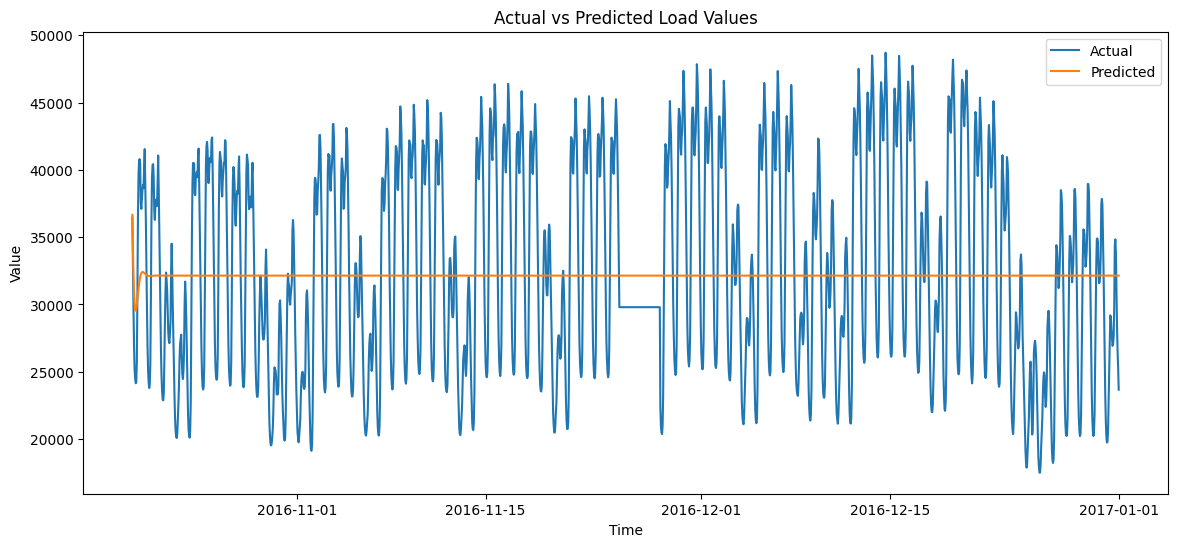

In [35]:
# Plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(df['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Actual vs Predicted Load Values')
plt.show()

While the ARIMA model captures general patterns, actual and predicted load values differ due to data randomness, unaccounted factors, or model limits. Complex models may improve results. Next, we will analyze the 'IT_solar_generation' series using ACF and PACF to determine ARIMA parameters.

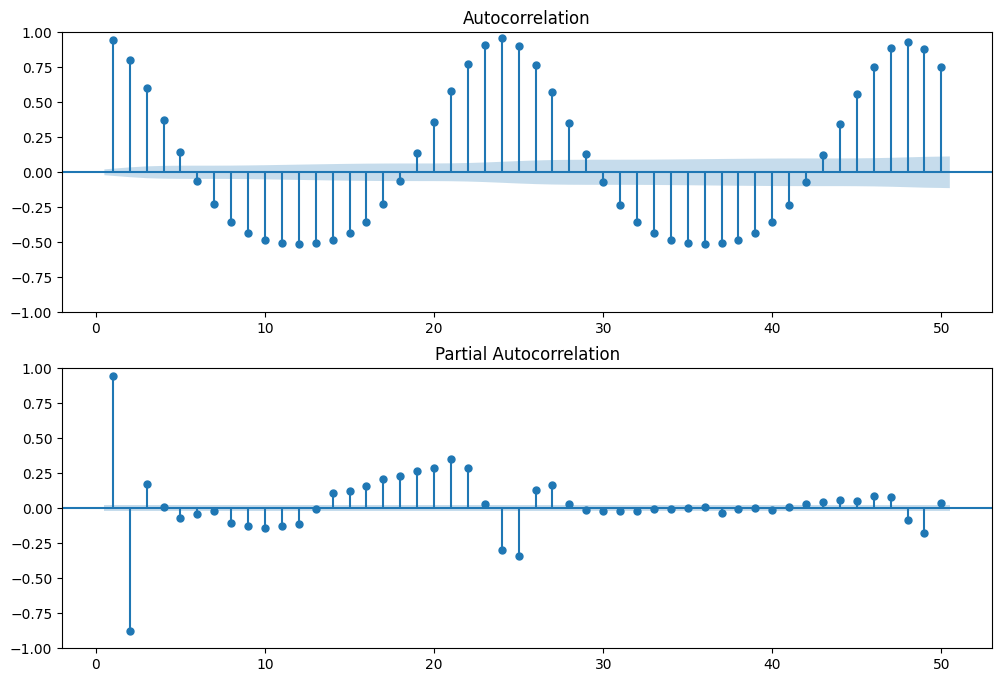

In [36]:
# Plot ACF and PACF for 'IT_solar_generation'
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
plot_acf(df['IT_solar_generation'], lags=50, zero=False, ax=ax1)
plot_pacf(df['IT_solar_generation'], lags=50, zero=False, ax=ax2)
plt.show()

In [37]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# Split the data into training and test sets
train_size = int(len(df['IT_solar_generation']) * 0.8)
train, test = df['IT_solar_generation'][:train_size], df['IT_solar_generation'][train_size:]

# Fit the ARIMA model
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

# Make predictions on the test set
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1)

# Calculate RMSE
rmse = sqrt(mean_squared_error(test, predictions))
rmse

2486.1507110911857

Like IT_load_new, the ARIMA model for IT_solar_generation has a 2486 RMSE measuring accuracy. Plot actual versus forecasted values to visualize performance.

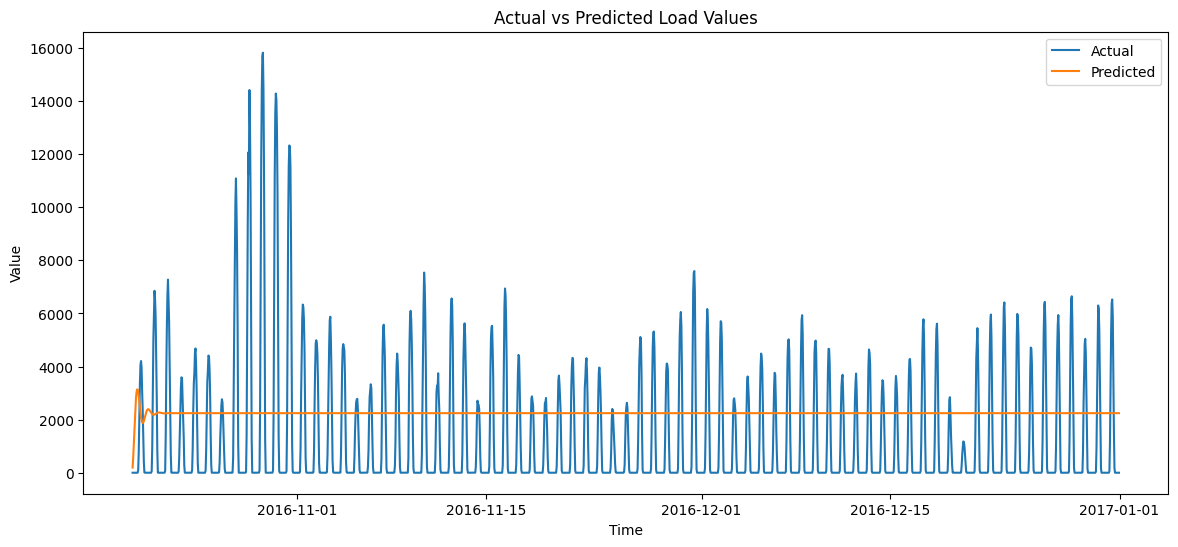

In [38]:
# Plot actual vs predicted values
plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(df['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title('Actual vs Predicted Load Values')
plt.show()

The test plot shows ARIMA capturing actual versus predicted solar generation patterns.